regresion lineal multiple

importacion de librerias para el laboratirio

In [3]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

ver variables del dataset

In [8]:
datos = pd.read_csv("dataset_2/Loan (1).csv")

print("Filas:", datos.shape[0])
print("Columnas:", datos.shape[1])

datos.head()

Filas: 20000
Columnas: 36


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [9]:
print("TIPO DE DATOS DE CADA VARIABLE")
print("=" * 50)

print(datos.dtypes)

TIPO DE DATOS DE CADA VARIABLE
ApplicationDate                   str
Age                             int64
AnnualIncome                    int64
CreditScore                     int64
EmploymentStatus                  str
EducationLevel                    str
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                     str
NumberOfDependents              int64
HomeOwnershipStatus               str
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory               int64
LoanPurpose                       str
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance           int64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities   

In [10]:
print("INFORMACIÓN DEL DATASET")
print("=" * 60)

datos.info()

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizat

In [11]:
print("VALORES ÚNICOS POR VARIABLE")
print("=" * 60)

for columna in datos.columns:
    print(f"{columna}: {datos[columna].nunique()} valores únicos")

VALORES ÚNICOS POR VARIABLE
ApplicationDate: 20000 valores únicos
Age: 63 valores únicos
AnnualIncome: 17516 valores únicos
CreditScore: 322 valores únicos
EmploymentStatus: 3 valores únicos
EducationLevel: 5 valores únicos
Experience: 62 valores únicos
LoanAmount: 15578 valores únicos
LoanDuration: 10 valores únicos
MaritalStatus: 4 valores únicos
NumberOfDependents: 6 valores únicos
HomeOwnershipStatus: 4 valores únicos
MonthlyDebtPayments: 1299 valores únicos
CreditCardUtilizationRate: 20000 valores únicos
NumberOfOpenCreditLines: 14 valores únicos
NumberOfCreditInquiries: 8 valores únicos
DebtToIncomeRatio: 20000 valores únicos
BankruptcyHistory: 2 valores únicos
LoanPurpose: 5 valores únicos
PreviousLoanDefaults: 2 valores únicos
PaymentHistory: 38 valores únicos
LengthOfCreditHistory: 29 valores únicos
SavingsAccountBalance: 9199 valores únicos
CheckingAccountBalance: 5151 valores únicos
TotalAssets: 18814 valores únicos
TotalLiabilities: 17163 valores únicos
MonthlyIncome: 17489

cargamos las variables del dataset para c=x y para y

In [12]:
# Eliminar variables de tipo texto
datos_numericos = datos.select_dtypes(exclude="str")

# Separar variables independientes y variable objetivo
X = datos_numericos.drop(columns=["RiskScore"])
y = datos_numericos["RiskScore"]

# Número de ejemplos
m = y.size

print("Número de ejemplos:", m)
print("Número de variables:", X.shape[1])

print("\nPrimeras filas de X:")
print(X.head())

print("\nPrimeros valores de y:")
print(y.head())

Número de ejemplos: 20000
Número de variables: 29

Primeras filas de X:
   Age  AnnualIncome  CreditScore  Experience  LoanAmount  LoanDuration  \
0   45         39948          617          22       13152            48   
1   38         39709          628          15       26045            48   
2   47         40724          570          26       17627            36   
3   58         69084          545          34       37898            96   
4   37        103264          594          17        9184            36   

   NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
0                   2                  183                   0.354418   
1                   1                  496                   0.087827   
2                   2                  902                   0.137414   
3                   1                  755                   0.267587   
4                   1                  274                   0.320535   

   NumberOfOpenCreditLines  ...  Total

normalizamos las variables

In [13]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

aplicamos la normalizacion

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

Desviación estandar calculada: Age                               11.622422
AnnualIncome                   40349.836385
CreditScore                       50.996083
Experience                        11.316553
LoanAmount                     13427.085527
LoanDuration                      24.664240
NumberOfDependents                 1.386290
MonthlyDebtPayments              240.501597
CreditCardUtilizationRate          0.159789
NumberOfOpenCreditLines            1.736118
NumberOfCreditInquiries            0.986940
DebtToIncomeRatio                  0.160207
BankruptcyHistory                  0.222832
PreviousLoanDefaults               0.300067
PaymentHistory                     4.945312
LengthOfCreditHistory              8.371343
SavingsAccountBalance           6604.722353
CheckingAccountBalance          2245.322677
TotalAssets                   120796.919182
TotalLiabilities               47250.329610
MonthlyIncome                   3296.689178
UtilityBillsPaymentHistory         0.120662
J

agregamos la columna de 1 a la matris

In [19]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)


In [24]:
print(X)

[[ 1.          0.45148937 -0.47617228 ... -0.72906227 -0.65238754
  -0.56041096]
 [ 1.         -0.15079473 -0.48209548 ... -0.1742642  -0.03637838
  -0.56041096]
 [ 1.          0.62357054 -0.45694048 ... -0.36349318  0.17696226
  -0.56041096]
 ...
 [ 1.          0.36544878 -0.25287521 ...  0.05013649 -0.13264194
  -0.56041096]
 [ 1.          1.74209816 -0.44948072 ... -0.74186709  0.01916834
  -0.56041096]
 [ 1.         -1.69952528 -0.14707553 ...  0.2049069  -0.30737917
  -0.56041096]]


funcion de costo

In [25]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

funcion descenso por gradiente

In [27]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

coheficientes de aprendizaje

theta calculado por el descenso por el gradiente:
[ 5.07644867e+01 -5.30661124e-02 -3.86591009e-01 -7.65025439e-01
 -1.17014714e-01 -2.08572470e-01 -2.36526926e-01 -2.71093126e-03
 -7.69758587e-02  7.54984892e-01 -7.13132012e-03  8.96269282e-03
  2.48780621e+00  2.61813176e+00  1.72490388e+00 -3.99702836e-03
 -9.38128855e-01 -1.33553700e-03 -1.22381925e-02 -6.77280627e-01
  2.09442789e-01 -4.00603875e-01  1.08586370e-02 -1.56037215e-02
 -8.13355962e-01  3.33571705e-01  7.49972708e-02 -1.53517005e-01
  3.82640124e-01 -4.48098491e+00]


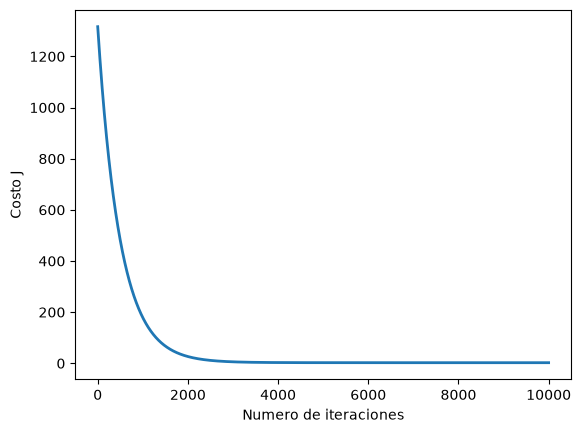

In [28]:
# Elegir algun valor para alpha
alpha = 0.001
num_iters = 10000

# Inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(30)

theta, J_history = gradientDescentMulti(
    X, y, theta, alpha, num_iters
)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente:')
print(theta)

In [35]:
# Seleccionamos el primer ejemplo de X
X_ejemplo = X[10]

# Realizamos la predicción
prediccion = np.dot(X_ejemplo, theta)

# Obtenemos el valor real
valor_real = y[10]

print("RiskScore real:", valor_real)
print("RiskScore predicho:", prediccion)
print("Error:", prediccion - valor_real)

RiskScore real: 47.0
RiskScore predicho: 50.09793812768151
Error: 3.097938127681509
